Your Goal: Your task it to predict listening time of a podcast episode.
Root Mean Squared Error (RMSE)
Submissions are scored on the root mean squared error. RMSE is defined as:

RMSE=(1N∑i=1N(yi−yˆi)2)12

where yˆi
 is the predicted value and yi
 is the original value for each instance i
.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

In [46]:
train_data= pd.read_csv("C:/devdev/Kaggle_contests/playground-series-s5e4/train.csv")

In [47]:
test_data= pd.read_csv("C:/devdev/Kaggle_contests/playground-series-s5e4/test.csv")

In [3]:
train_data.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031


EDA

In [6]:
def looking_at_the_data(df):
    return df.shape, df.info(), df.describe(), df.isna().sum()

In [7]:
looking_at_the_data(train_data)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           750000 non-null  int64  
 1   Podcast_Name                 750000 non-null  object 
 2   Episode_Title                750000 non-null  object 
 3   Episode_Length_minutes       662907 non-null  float64
 4   Genre                        750000 non-null  object 
 5   Host_Popularity_percentage   750000 non-null  float64
 6   Publication_Day              750000 non-null  object 
 7   Publication_Time             750000 non-null  object 
 8   Guest_Popularity_percentage  603970 non-null  float64
 9   Number_of_Ads                749999 non-null  float64
 10  Episode_Sentiment            750000 non-null  object 
 11  Listening_Time_minutes       750000 non-null  float64
dtypes: float64(5), int64(1), object(6)
memory usage: 68.7+ MB


((750000, 12),
 None,
                   id  Episode_Length_minutes  Host_Popularity_percentage  \
 count  750000.000000           662907.000000               750000.000000   
 mean   374999.500000               64.504738                   59.859901   
 std    216506.495284               32.969603                   22.873098   
 min         0.000000                0.000000                    1.300000   
 25%    187499.750000               35.730000                   39.410000   
 50%    374999.500000               63.840000                   60.050000   
 75%    562499.250000               94.070000                   79.530000   
 max    749999.000000              325.240000                  119.460000   
 
        Guest_Popularity_percentage  Number_of_Ads  Listening_Time_minutes  
 count                603970.000000  749999.000000           750000.000000  
 mean                     52.236449       1.348855               45.437406  
 std                      28.451241       1.151130  

In [14]:
train_data["Genre"].value_counts()

Genre
Sports        87606
Technology    86256
True Crime    85059
Lifestyle     82461
Comedy        81453
Business      80521
Health        71416
News          63385
Music         62743
Education     49100
Name: count, dtype: int64

C:\Users\Vidushi\AppData\Local\Temp\ipykernel_6544\1578021308.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=train_data["Genre"], y=train_data["Listening_Time_minutes"], palette="viridis")


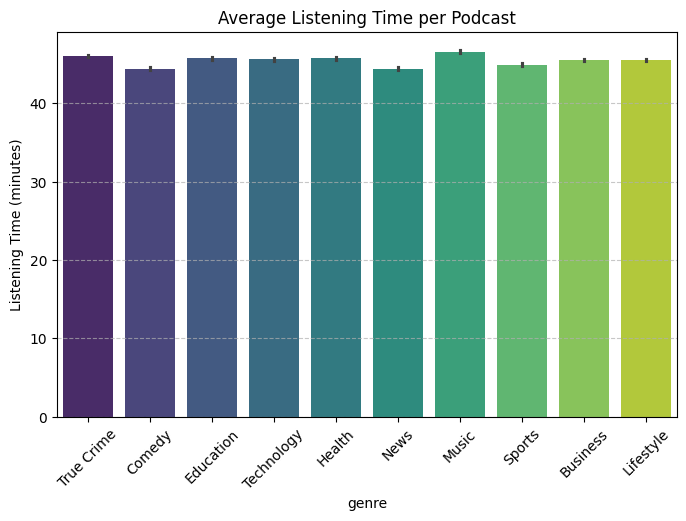

In [16]:
# Plot 1: Bar plot of Listening Time by Podcast Name
plt.figure(figsize=(8,5))
sns.barplot(x=train_data["Genre"], y=train_data["Listening_Time_minutes"], palette="viridis")
plt.xlabel("genre")
plt.ylabel("Listening Time (minutes)")
plt.title("Average Listening Time per Podcast")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

C:\Users\Vidushi\AppData\Local\Temp\ipykernel_6544\1167210174.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=train_data["Number_of_Ads"], y=train_data["Listening_Time_minutes"], palette="magma")


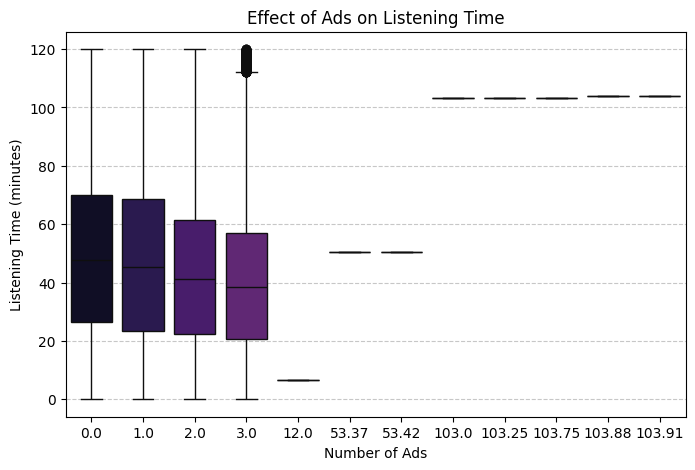

In [ ]:
# Plot 2: Ads vs. Listening Time (Boxplot)
plt.figure(figsize=(8,5))
sns.boxplot(x=train_data["Number_of_Ads"], y=train_data["Listening_Time_minutes"], palette="magma")
plt.xlabel("Number of Ads")
plt.ylabel("Listening Time (minutes)")
plt.title("Effect of Ads on Listening Time")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
train_data.head(20)

,id,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,...,Podcast_TFIDF_77,Podcast_TFIDF_78,Podcast_TFIDF_79,Podcast_TFIDF_80,Podcast_TFIDF_81,Podcast_TFIDF_82,Podcast_TFIDF_83,Podcast_TFIDF_84,Podcast_TFIDF_85,Podcast_TFIDF_86
0,0,1.692785,NaN,9,0.653611,4,3,NaN,-1.171766,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,-1.109957,1.677159,1,0.309975,2,0,0.833480,0.565657,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,-1.500212,0.284967,2,0.442008,5,1,-1.520723,-1.171766,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,-0.364924,0.080840,8,-0.115415,1,2,0.930137,0.565657,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,1.231574,1.395384,3,0.883575,1,0,0.226477,1.434368,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
numerical_features = ['Episode_Length_minutes', 'Host_Popularity_percentage', 'Guest_Popularity_percentage', 'Number_of_Ads' ]

categorical_features = [
    "Podcast_Name",
    "Episode_Title",
    "Genre",
    "Publication_Day",
    "Publication_Time",
]

In [39]:
train_data.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031


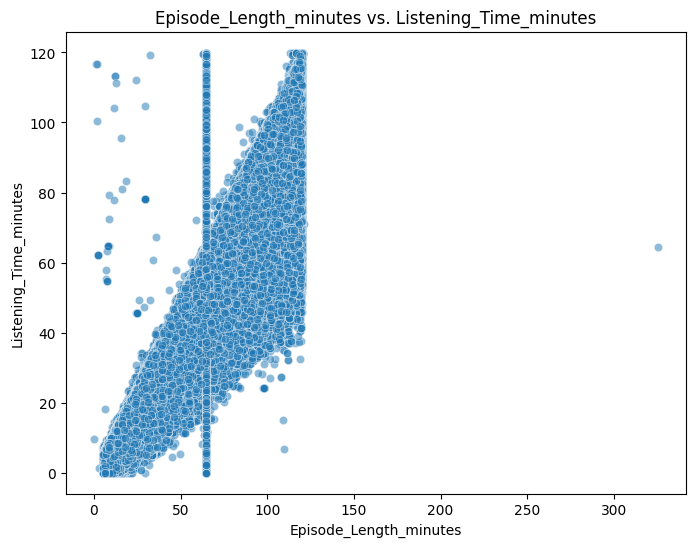

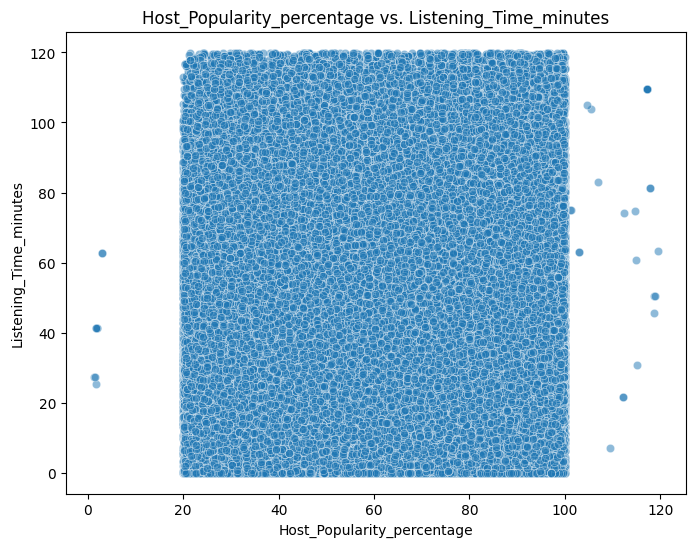

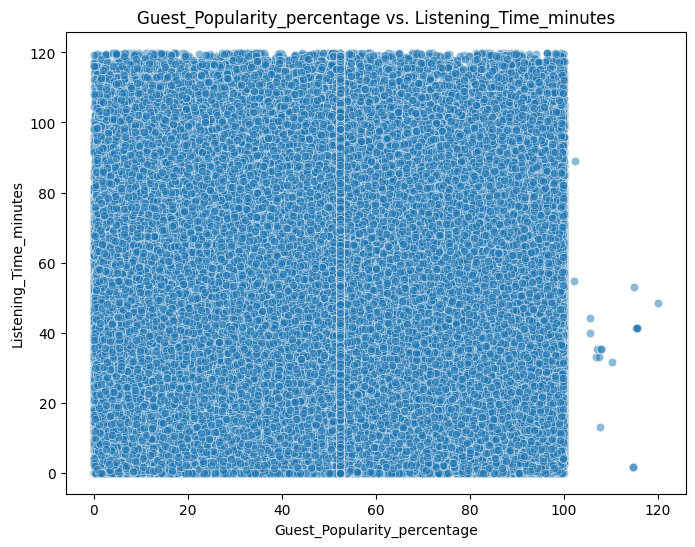

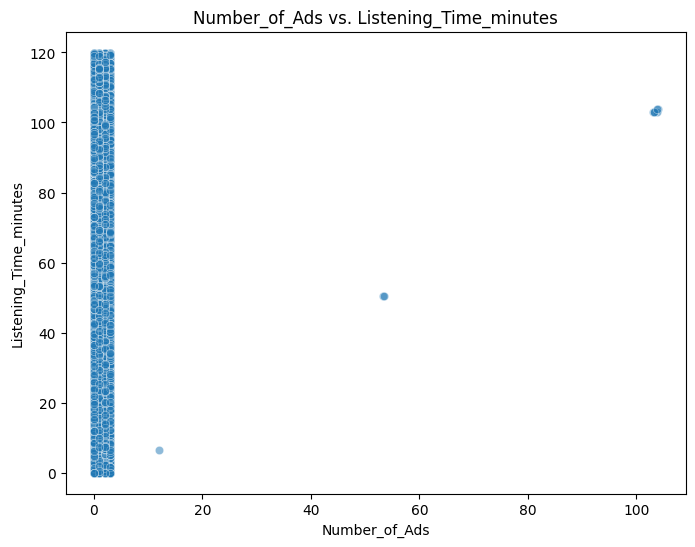

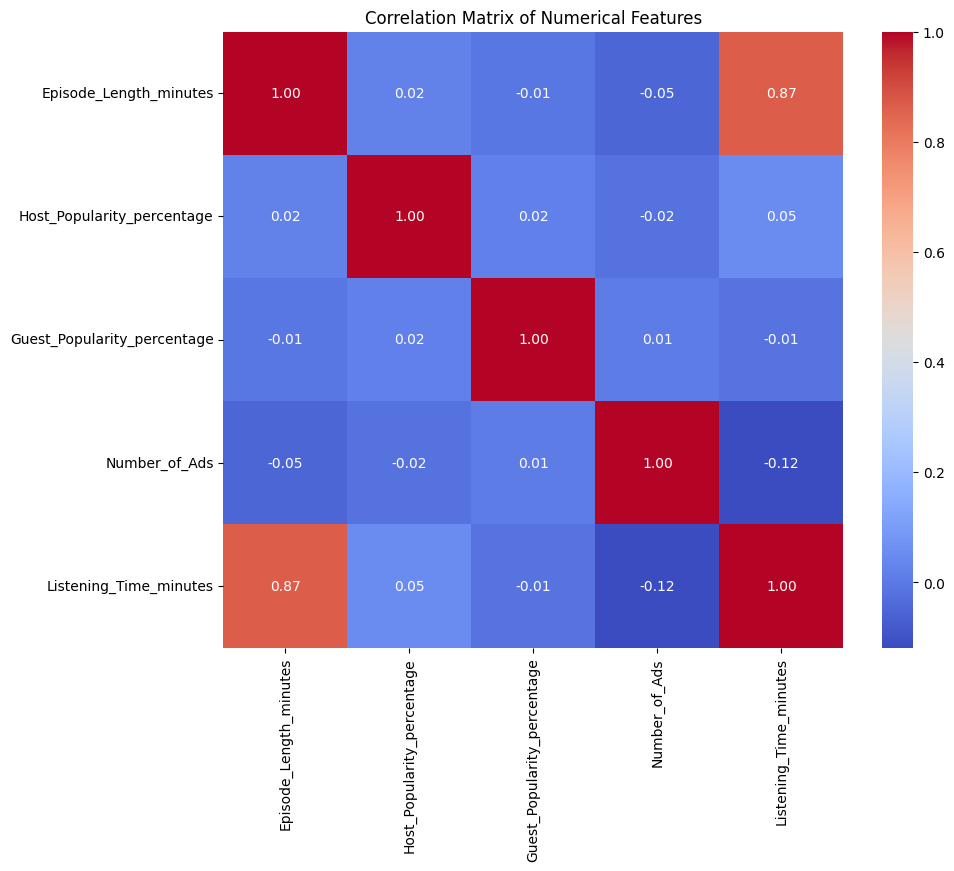

In [ ]:
# Scatter plots for numerical features vs. Label
for feature in numerical_features[:-1]:  # Exclude Label itself
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x=train_data[feature], y=train_data["Listening_Time_minutes"], alpha=0.5
    )
    plt.title(f"{feature} vs. Listening_Time_minutes")
    plt.xlabel(feature)
    plt.ylabel("Listening_Time_minutes")
    plt.show()

# Correlation matrix for numerical features
correlation_matrix = train_data[numerical_features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

Episode Length strongly affects Listening Time (0.87), so it should be a key feature.

Number of Ads slightly reduces Listening Time (-0.12), meaning ads may cause drop-offs.

Host and Guest Popularity have almost no impact, so they are not useful predictors.

For modeling, focus on Episode Length and Ads, and consider removing popularity metrics to simplify the model.

needs feature engineering :) 

In [30]:
def segment_percentage(percentage):
    if percentage <= 20:
        return '0-20'
    elif percentage <= 40:
        return '20-40'
    elif percentage <= 60:
        return '40-60'
    elif percentage <= 80:
        return '60-80'
    elif percentage <= 100:
        return '80-100'
    else:
        return '100+'

In [31]:
def feature_engineering(df):
    
    columns = ['Podcast_Name', 'Episode_Title']
    for col in columns:
        counts = df[col].value_counts(normalize=True)
        df[f'{col}_popularity'] = df[col].map(counts)
        
    df['Host_Popularity_percentage_segment'] = df['Host_Popularity_percentage'].apply(segment_percentage)
    df['Guest_Popularity_percentage_segment'] = df['Guest_Popularity_percentage'].apply(segment_percentage)
    
    df['Host_vs_Guest_Popularity'] = df['Host_Popularity_percentage'] / (df['Guest_Popularity_percentage'] + 1)
    df['Total_Popularity'] = df['Host_Popularity_percentage'] + df['Guest_Popularity_percentage']
    df['Very_Popular_Guest'] = ((df['Guest_Popularity_percentage'] > 50) & (df['Guest_Popularity_percentage'] < 55)).astype(int)
    df['Avg_Episode_Length_By_Genre'] = df.groupby('Genre')['Episode_Length_minutes'].transform('mean')
    
    df['Ads_per_Minute'] = df['Number_of_Ads'] / (df['Episode_Length_minutes'] + 1)
    df['Has_Ads'] = (df['Number_of_Ads'] > 0).astype(int)
    df['Ads_Intensity'] = pd.cut(df['Number_of_Ads'], bins=[-1, 0, 2, 3], labels=['No Ads', 'Few Ads', 'Many Ads'])
    
    df['Has_Sport'] = df['Podcast_Name'].str.contains(r'\b(Sports|Sport|Arena)\b', case=False, na=False).astype(int)
    df['Has_Music'] = df['Podcast_Name'].str.contains(r'\b(Music|Melody|Sound|Tune)\b', case=False, na=False).astype(int)
    df['Has_Comedy'] = df['Podcast_Name'].str.contains(r'\b(Joke|Funny|Comedy|Laugh|Humor)\b', case=False, na=False).astype(int)
    df['Has_Crime'] = df['Podcast_Name'].str.contains(r'\b(Mystery|Criminal|Crime|Detective)\b', case=False, na=False).astype(int)
    df['Has_Education'] = df['Podcast_Name'].str.contains(r'\b(Study|Educational|Learning|Brain)\b', case=False, na=False).astype(int)
    df['Has_Finance'] = df['Podcast_Name'].str.contains(r'\b(Business|Market|Money|Finance)\b', case=False, na=False).astype(int)
    
    # by yunsuxiaozi (https://www.kaggle.com/code/yunsuxiaozi/pss5e4-xgb-baseline)
    df['Episode_Title_num']=df['Episode_Title'].apply(lambda x:int(x[len('Episode '):]))
    df['sin_Episode_Title_num']=np.sin(2*np.pi*df['Episode_Title_num']/12)
    df['cos_Episode_Title_num']=np.cos(2*np.pi*df['Episode_Title_num']/12)
    df['sin_Episode_Length_minutes']=np.sin(2*np.pi*df['Episode_Length_minutes']/60)
    df['cos_Episode_Length_minutes']=np.cos(2*np.pi*df['Episode_Length_minutes']/60)
    
    new_features = ['Podcast_Name_popularity', 'Episode_Title_popularity', 'Host_Popularity_percentage_segment', 'Guest_Popularity_percentage_segment', 'Host_vs_Guest_Popularity', 'Ads_per_Minute', 'Total_Popularity', 'Avg_Episode_Length_By_Genre', 'Very_Popular_Guest', 'Has_Ads', 'Ads_Intensity', 'Episode_Title_num', 'sin_Episode_Title_num', 'cos_Episode_Title_num', 'sin_Episode_Length_minutes', 'cos_Episode_Length_minutes', 'Has_Sport', 'Has_Music', 'Has_Comedy', 'Has_Crime', 'Has_Education', 'Has_Finance']
    
    return df, new_features
train_data, new_features = feature_engineering(train_data)
test_data, new_features = feature_engineering(test_data)

C:\Users\Vidushi\AppData\Local\Temp\ipykernel_17280\3901245421.py:20: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['Has_Sport'] = df['Podcast_Name'].str.contains(r'\b(Sports|Sport|Arena)\b', case=False, na=False).astype(int)
C:\Users\Vidushi\AppData\Local\Temp\ipykernel_17280\3901245421.py:21: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['Has_Music'] = df['Podcast_Name'].str.contains(r'\b(Music|Melody|Sound|Tune)\b', case=False, na=False).astype(int)
C:\Users\Vidushi\AppData\Local\Temp\ipykernel_17280\3901245421.py:22: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['Has_Comedy'] = df['Podcast_Name'].str.contains(r'\b(Joke|Funny|Comedy|Laugh|Humor)\b', case=False, na=False).astype(int)
C:\Users\Vidushi\AppData\Loca

In [39]:
train_data.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,...,Has_Music,Has_Comedy,Has_Crime,Has_Education,Has_Finance,Episode_Title_num,sin_Episode_Title_num,cos_Episode_Title_num,sin_Episode_Length_minutes,cos_Episode_Length_minutes
0,0,Mystery Matters,Episode 98,63.84,True Crime,74.81,Thursday,Night,53.58,0.0,...,0,0,1,0,0,98,0.866025,5.000000e-01,NaN,NaN
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,...,0,1,0,0,0,26,0.866025,5.000000e-01,-0.020942,0.999781
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,...,0,0,0,1,0,16,0.866025,-5.000000e-01,0.993373,0.114937
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,...,0,0,0,0,0,45,-1.000000,8.578717e-16,0.682254,0.731116
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,...,0,0,0,0,0,86,0.866025,5.000000e-01,-0.838100,0.545517


In [7]:
num_cols= ['Episode_Length_minutes', 'Host_Popularity_percentage', 'Guest_Popularity_percentage', 'Number_of_Ads', 'Has_Music', 'Has_Comedy', 'Has_Crime', 'Has_Education', 'Has_Finance', 'Episode_Title_num', 'sin_Episode_Title_num', 'cos_Episode_Title_num', 'sin_Episode_Length_minutes', 'cos_Episode_Length_minutes']
cat_cols=['Episode_Title', 'Genre', 'Publication_Day', 'Publication_Time']

Preprocess 

convert all cat cols -> label encoder and podcast_name-> tfidf 

normalize numerical cols too 

In [48]:
print("Missing Values per Column:")
print(train_data.isnull().sum())

# Impute numerical features with median
num_imputer = SimpleImputer(strategy="median")
train_data[numerical_features] = num_imputer.fit_transform(
    train_data[numerical_features]
)

# Impute categorical features with mode (most frequent value)
cat_imputer = SimpleImputer(strategy="most_frequent")
train_data[categorical_features] = cat_imputer.fit_transform(
    train_data[categorical_features]
)

# Verify no missing values remain
print("\nMissing Values After Imputation:")
print(train_data.isnull().sum())

num_imputer = SimpleImputer(strategy="median")
test_data[numerical_features] = num_imputer.fit_transform(
    test_data[numerical_features]
)

# Impute categorical features with mode (most frequent value)
cat_imputer = SimpleImputer(strategy="most_frequent")
test_data[categorical_features] = cat_imputer.fit_transform(
    test_data[categorical_features]
)

Missing Values per Column:
id                                  0
Podcast_Name                        0
Episode_Title                       0
Episode_Length_minutes          87093
Genre                               0
Host_Popularity_percentage          0
Publication_Day                     0
Publication_Time                    0
Guest_Popularity_percentage    146030
Number_of_Ads                       1
Episode_Sentiment                   0
Listening_Time_minutes              0
dtype: int64

Missing Values After Imputation:
id                             0
Podcast_Name                   0
Episode_Title                  0
Episode_Length_minutes         0
Genre                          0
Host_Popularity_percentage     0
Publication_Day                0
Publication_Time               0
Guest_Popularity_percentage    0
Number_of_Ads                  0
Episode_Sentiment              0
Listening_Time_minutes         0
dtype: int64


In [10]:
train_data.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,...,Has_Music,Has_Comedy,Has_Crime,Has_Education,Has_Finance,Episode_Title_num,sin_Episode_Title_num,cos_Episode_Title_num,sin_Episode_Length_minutes,cos_Episode_Length_minutes
0,0,Mystery Matters,98,63.84,9,74.81,4,3,53.58,0.0,...,0.0,0.0,1.0,0.0,0.0,98.0,0.866025,5.000000e-01,-0.160570,-0.083678
1,1,Joke Junction,19,119.80,1,66.95,2,0,75.95,2.0,...,0.0,1.0,0.0,0.0,0.0,26.0,0.866025,5.000000e-01,-0.020942,0.999781
2,2,Study Sessions,8,73.90,2,69.97,5,1,8.97,0.0,...,0.0,0.0,0.0,1.0,0.0,16.0,0.866025,-5.000000e-01,0.993373,0.114937
3,3,Digital Digest,40,67.17,8,57.22,1,2,78.70,2.0,...,0.0,0.0,0.0,0.0,0.0,45.0,-1.000000,8.578717e-16,0.682254,0.731116
4,4,Mind & Body,85,110.51,3,80.07,1,0,58.68,3.0,...,0.0,0.0,0.0,0.0,0.0,86.0,0.866025,5.000000e-01,-0.838100,0.545517


In [49]:
from sklearn.preprocessing import LabelEncoder

#apply label encoding on these cat cols
for col in categorical_features:
    le= LabelEncoder()
    train_data[col]= le.fit_transform(train_data[col])
    test_data[col]= le.fit_transform(test_data[col])

In [50]:
train_data['Episode_Sentiment']= le.fit_transform(train_data['Episode_Sentiment'])
test_data['Episode_Sentiment']= le.fit_transform(test_data['Episode_Sentiment'])

In [51]:
#apply tfidf vectorization on podcast name as it got 2 words
from sklearn.feature_extraction.text import TfidfVectorizer
vec= TfidfVectorizer()
train_podcast_tfidf= vec.fit_transform(train_data['Podcast_Name'].astype(str))
test_podcat_tfidf= vec.fit_transform(test_data['Podcast_Name'].astype(str))

In [52]:
train = train_data.reset_index(drop=True)
test = test_data.reset_index(drop=True)
# Convert sparse matrix to DataFrame
train_podcast_df = pd.DataFrame(train_podcast_tfidf.toarray(), columns=[f'Podcast_TFIDF_{i}' for i in range(train_podcast_tfidf.shape[1])])
test_podcast_df = pd.DataFrame(test_podcat_tfidf.toarray(), columns=[f'Podcast_TFIDF_{i}' for i in range(test_podcat_tfidf.shape[1])])

In [53]:
# Concatenate TF-IDF features
train_data = pd.concat([train_data, train_podcast_df], axis=1)
test_data = pd.concat([test_data, test_podcast_df], axis=1)

In [54]:
train_data= train_data.drop(columns=['Podcast_Name'])
test_data= test_data.drop(columns=['Podcast_Name'])

In [62]:
train_data.head()

,id,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,...,Podcast_TFIDF_77,Podcast_TFIDF_78,Podcast_TFIDF_79,Podcast_TFIDF_80,Podcast_TFIDF_81,Podcast_TFIDF_82,Podcast_TFIDF_83,Podcast_TFIDF_84,Podcast_TFIDF_85,Podcast_TFIDF_86
0,0,98,-0.018955,9,74.81,4,3,53.58,0.0,Positive,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,19,1.786381,1,66.95,2,0,75.95,2.0,Negative,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,8,0.305593,2,69.97,5,1,8.97,0.0,Negative,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,40,0.088475,8,57.22,1,2,78.70,2.0,Positive,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,85,1.486675,3,80.07,1,0,58.68,3.0,Neutral,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [55]:
# Normalize numerical features
for col in numerical_features:
    train_data[col] = train_data[col].astype('float32')
    test_data[col] = test_data[col].astype('float32')
    mean_val = train_data[col].mean()  
    std_val = train_data[col].std()    
    train_data[col] = (train_data[col] - mean_val) / std_val
    test_data[col] = (test_data[col] - mean_val) / std_val

In [65]:
train_data.head()

,id,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,...,Podcast_TFIDF_77,Podcast_TFIDF_78,Podcast_TFIDF_79,Podcast_TFIDF_80,Podcast_TFIDF_81,Podcast_TFIDF_82,Podcast_TFIDF_83,Podcast_TFIDF_84,Podcast_TFIDF_85,Podcast_TFIDF_86
0,0,98,-0.018955,9,0.653610,4,3,0.042368,-1.171766,Positive,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,19,1.786381,1,0.309975,2,0,0.918346,0.565658,Negative,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,8,0.305593,2,0.442008,5,1,-1.704499,-1.171766,Negative,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,40,0.088475,8,-0.115415,1,2,1.026032,0.565658,Positive,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,85,1.486675,3,0.883575,1,0,0.242077,1.434370,Neutral,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [56]:
X= train_data.drop(columns=['Listening_Time_minutes'])
y= train_data['Listening_Time_minutes']

for col in categorical_features:
    train_data[col] = train_data[col].astype("category")  
    test_data[col] = test_data[col].astype("category")  

test_data["Episode_Sentiment"]= test_data["Episode_Sentiment"].astype("category").cat.codes

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)  # 70% train, 30% temp

#X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=1)

X_train["Episode_Sentiment"] = X_train["Episode_Sentiment"].astype("category").cat.codes
X_test["Episode_Sentiment"] = X_test["Episode_Sentiment"].astype("category").cat.codes

In [71]:
train_data.head()

,id,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,...,Podcast_TFIDF_77,Podcast_TFIDF_78,Podcast_TFIDF_79,Podcast_TFIDF_80,Podcast_TFIDF_81,Podcast_TFIDF_82,Podcast_TFIDF_83,Podcast_TFIDF_84,Podcast_TFIDF_85,Podcast_TFIDF_86
0,0,98,-0.018955,9,0.653610,4,3,0.042368,-1.171766,Positive,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,19,1.786381,1,0.309975,2,0,0.918346,0.565658,Negative,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,8,0.305593,2,0.442008,5,1,-1.704499,-1.171766,Negative,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,40,0.088475,8,-0.115415,1,2,1.026032,0.565658,Positive,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,85,1.486675,3,0.883575,1,0,0.242077,1.434370,Neutral,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [42]:
train_data['Episode_Sentiment']

0         2
1         0
2         0
3         2
4         1
         ..
749995    0
749996    1
749997    0
749998    0
749999    1
Name: Episode_Sentiment, Length: 750000, dtype: int32

In [ ]:
import optuna
import xgboost as xgb
from sklearn.metrics import root_mean_squared_error
def objective(trial):
    params = {
        'n_estimators': 1000,
        'learning_rate': 0.03,
        'max_depth': trial.suggest_int('max_depth', 6, 12), 
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.8),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 2.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 10.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 10.0),
        'eval_metric': 'rmse',
        'random_state': 42,
        'tree_method': 'hist',
        'verbosity': 0
    }
    model = xgb.XGBRegressor(**params)
    model.fit(
        X_train, y_train,
    )
    preds = model.predict(X_test)
    rmse = root_mean_squared_error(y_test, preds)
    return rmse  
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)
print("Best Trial RMSE:", study.best_value)
print("Best Params:", study.best_params)

[I 2025-04-05 09:29:14,586] A new study created in memory with name: no-name-79a47a66-14c5-45b5-9d09-359240065273
[I 2025-04-05 09:30:29,523] Trial 0 finished with value: 12.989566341768551 and parameters: {'max_depth': 8, 'min_child_weight': 8, 'colsample_bytree': 0.5002739316376261, 'subsample': 0.9008496771814537, 'gamma': 0.46341501211307445, 'reg_alpha': 6.2569517434121105, 'reg_lambda': 0.9990672724900374}. Best is trial 0 with value: 12.989566341768551.
[I 2025-04-05 09:31:39,258] Trial 1 finished with value: 13.041527201305943 and parameters: {'max_depth': 6, 'min_child_weight': 1, 'colsample_bytree': 0.7175775570880379, 'subsample': 0.6637489314619287, 'gamma': 0.5945372435978997, 'reg_alpha': 9.166516555363897, 'reg_lambda': 8.393506673835827}. Best is trial 0 with value: 12.989566341768551.
[I 2025-04-05 09:33:04,847] Trial 2 finished with value: 12.935237494861441 and parameters: {'max_depth': 9, 'min_child_weight': 1, 'colsample_bytree': 0.6053270355534975, 'subsample': 0.

Best Trial RMSE: 12.819078771050197
Best Params: {'max_depth': 12, 'min_child_weight': 9, 'colsample_bytree': 0.7748920188471545, 'subsample': 0.938770305524631, 'gamma': 1.4299406046201915, 'reg_alpha': 1.2084476922636158, 'reg_lambda': 1.2109173126517754}


In [20]:
best_params = study.best_params

best_params.update({
    'n_estimators': 1000,
    'learning_rate': 0.03,
    'eval_metric': 'rmse',
    'random_state': 42,
    'tree_method': 'hist',
    'verbosity': 0
})

# Train final model
final_model = xgb.XGBRegressor(**best_params)
final_model.fit(X_train, y_train)

NameError: name 'study' is not defined

In [ ]:
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from bayes_opt import BayesianOptimization
def xgb_cv(max_depth, learning_rate, subsample, colsample_bytree, reg_alpha, reg_lambda):
    params = {
        'max_depth': int(max_depth),
        'learning_rate': learning_rate,
        'subsample': subsample,
        'colsample_bytree': colsample_bytree,
        'reg_alpha': reg_alpha,
        'reg_lambda': reg_lambda,
        'n_estimators': 10000,
        'eval_metric': 'rmse',
        'early_stopping_rounds': 100,
    }

    cv_scores = []
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    for train_idx, val_idx in kf.split(X_train):
        x_tr = X_train.iloc[train_idx]
        y_tr = y_train.iloc[train_idx]
        x_va = X_train.iloc[val_idx]
        y_va = y_train.iloc[val_idx]

        model = xgb.XGBRegressor(**params)
        model.fit(
            x_tr, y_tr,
            eval_set=[(x_va, y_va)],
            verbose=False
        )

        val_pred = model.predict(x_va)
        val_rmse = root_mean_squared_error(y_va, val_pred)
        cv_scores.append(val_rmse)

    mean_rmse = np.mean(cv_scores)
    print(f"Mean RMSE: {mean_rmse:.3f}")
    return -mean_rmse

pbounds = {
    'max_depth': (5, 12),
    'learning_rate': (0.01, 0.3),
    'subsample': (0.8, 1),
    'colsample_bytree': (0.8, 1),
    'reg_alpha': (0.1, 1),
    'reg_lambda': (0.1, 1)
}
optimizer = BayesianOptimization(
    f=xgb_cv,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)

optimizer.maximize(init_points=3, n_iter=5)

best_params = optimizer.max['params']
best_params['max_depth'] = int(best_params['max_depth'])
print('Best paras', best_params)

|   iter    |  target   | colsam... | learni... | max_depth | reg_alpha | reg_la... | subsample |
-------------------------------------------------------------------------------------------------
Mean RMSE: 13.143
| 1         | -13.14    | 0.8749    | 0.2857    | 10.12     | 0.6388    | 0.2404    | 0.8312    |
Mean RMSE: 13.081
| 2         | -13.08    | 0.8116    | 0.2612    | 9.208     | 0.7373    | 0.1185    | 0.994     |
Mean RMSE: 13.005
| 3         | -13.01    | 0.9665    | 0.07158   | 6.273     | 0.2651    | 0.3738    | 0.905     |
Mean RMSE: 13.005
| 4         | -13.01    | 0.8864    | 0.09446   | 9.283     | 0.2255    | 0.3629    | 0.8733    |
Mean RMSE: 13.068
| 5         | -13.07    | 0.8912    | 0.2377    | 6.398     | 0.5628    | 0.6332    | 0.8093    |
Mean RMSE: 13.012
| 6         | -13.01    | 0.9215    | 0.05945   | 5.455     | 0.954     | 0.9691    | 0.9617    |
Mean RMSE: 12.952
| 7         | -12.95    | 0.8609    | 0.03832   | 9.79      | 0.4961    | 0.2098    | 0.89

In [59]:
import lightgbm as lgb

params = {
    'max_depth': 12,
    'reg_alpha': 1.2084476922636158,
    'reg_lambda': 1.2109173126517754,
    'colsample_bytree': 0.7748920188471545,
    'subsample': 0.938770305524631,
    'learning_rate': 0.1,
    'n_estimators': 1000,
    'objective': 'regression',
    'metric': 'rmse',
    'random_state': 42,
    'verbosity': -1
}

model_lgb = lgb.LGBMRegressor(**params)

model_lgb.fit(
    X_train, y_train,
    eval_metric='rmse',
)

LGBMRegressor(colsample_bytree=0.7748920188471545, max_depth=12, metric='rmse',
              n_estimators=1000, objective='regression', random_state=42,
              reg_alpha=1.2084476922636158, reg_lambda=1.2109173126517754,
              subsample=0.938770305524631, verbosity=-1)

In [76]:
from catboost import CatBoostRegressor
model_cat = CatBoostRegressor(
        iterations=1500,
        learning_rate=0.08777255350163136,
        depth=10,
        l2_leaf_reg=0.1259643500248322,
        bootstrap_type='Bayesian',
        random_strength=4.276181166674371e-08,
        bagging_temperature=0.35995482350907326,
        od_type='Iter',
        od_wait=39,
        verbose=200,
        allow_writing_files=False,
        random_seed=42
    )
    
    # Train CatBoost model
model_cat.fit(
        X_train, y_train,
    )

0:	learn: 25.3643680	total: 394ms	remaining: 9m 50s
200:	learn: 12.8982245	total: 43.3s	remaining: 4m 39s
400:	learn: 12.6348739	total: 1m 26s	remaining: 3m 57s
600:	learn: 12.4013170	total: 2m 9s	remaining: 3m 13s
800:	learn: 12.1846422	total: 2m 53s	remaining: 2m 31s
1000:	learn: 11.9811464	total: 3m 36s	remaining: 1m 47s
1200:	learn: 11.7925041	total: 4m 18s	remaining: 1m 4s
1400:	learn: 11.6127134	total: 5m 1s	remaining: 21.3s
1499:	learn: 11.5280410	total: 5m 22s	remaining: 0us


In [80]:
from lightgbm import LGBMRegressor

model_lgbm = LGBMRegressor(
    n_estimators=3500,
    random_state=42,
    max_bin=1024,
    colsample_bytree=0.6,
    reg_lambda=80,
    verbosity=-1,
    num_leaves=64,  
    max_depth=15,  
    learning_rate=0.05,  
    feature_fraction=0.8,  
    bagging_fraction=0.8,  
    lambda_l1=0.1, 
    lambda_l2=0.1 
)
model_lgbm.fit(X_train, y_train)

LGBMRegressor(bagging_fraction=0.8, colsample_bytree=0.6, feature_fraction=0.8,
              lambda_l1=0.1, lambda_l2=0.1, learning_rate=0.05, max_bin=1024,
              max_depth=15, n_estimators=3500, num_leaves=64, random_state=42,
              reg_lambda=80, verbosity=-1)

In [60]:
from sklearn.metrics import mean_squared_error

In [61]:
pred=model_lgb.predict(X_test)
mse = np.sqrt(mean_squared_error(y_test, pred))
print(mse)

13.052136443822231


In [44]:
test_data.head()

,id,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,...,Podcast_TFIDF_28,Podcast_TFIDF_29,Podcast_TFIDF_30,Podcast_TFIDF_31,Podcast_TFIDF_32,Podcast_TFIDF_33,Podcast_TFIDF_34,Podcast_TFIDF_35,Podcast_TFIDF_36,Podcast_TFIDF_37
0,750000,71,0.468834,2,-0.950895,2,1,0.032578,-0.303054,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,750001,16,-1.179390,5,0.499718,3,2,NaN,-1.171766,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,750002,3,0.150739,1,0.351071,0,1,1.762607,-1.171766,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,750003,71,1.644109,1,-1.594008,3,2,-0.029293,0.565658,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,750004,46,0.254620,4,-0.076942,6,2,-1.613260,0.565658,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [78]:
X_train.head()

,id,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,...,Podcast_TFIDF_77,Podcast_TFIDF_78,Podcast_TFIDF_79,Podcast_TFIDF_80,Podcast_TFIDF_81,Podcast_TFIDF_82,Podcast_TFIDF_83,Podcast_TFIDF_84,Podcast_TFIDF_85,Podcast_TFIDF_86
334534,334534,38,1.088894,9,1.071569,3,0,1.266858,0.565658,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
147174,147174,65,-0.018955,6,0.142529,6,1,1.251194,-1.171766,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
194519,194519,28,1.448929,5,1.235517,6,0,1.118447,-1.171766,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
673260,673260,60,-0.228975,1,-1.395522,2,3,0.042368,1.434370,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
650888,650888,5,-0.018955,4,0.375117,5,1,-0.863763,1.434370,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [72]:
predicts= final_model.predict(test_data)

In [73]:
df = pd.DataFrame({'id': test_data["id"], 'Listening_Time_minutes': predicts})

df.to_csv('predictions.csv', index=False)

import optuna.visualization as vis

fig = vis.plot_optimization_history(study)
fig.write_html("optuna_optimization_history.html", auto_open=True)
